> 选择 CartPole 环境  
> 对比离散型动作输出算法： DQN，Actor-Critic，TPRO-concrete，PPO-concrete，SAC-concrete

In [1]:
import os
import sys
import random
import collections
from tqdm import tqdm
import matplotlib.pyplot as plt

try:
    base_path = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    base_path = os.path.dirname(os.getcwd())

if base_path not in sys.path:
    sys.path.insert(0, base_path)

import torch
import torch.nn.functional as F
import gymnasium as gym
import numpy as np

from src.utils import rl_utils
from src.utils.rl_utils import ReplayBuffer
from src.utils.rl_utils import plot_returns_combined
from src.utils.rl_utils import show_live_performance
from src.agents.myDQN import DQN as MyDQN
from src.agents.myActorCritic import ActorCritic as MyActorCritic
from src.agents.myTRPO import TRPO as MyTRPO
from src.agents.myTRPOcontinuous import TRPOContinuous as MyTRPOContinuous
from src.agents.myPPO import PPO as MyPPO
from src.agents.myPPOcontinuous import PPOContinuous as MyPPOContinuous
from src.agents.mySAC import SAC as MySAC
from src.agents.mySACcontinuous import SACContinuous as MySACContinuous

> 不同 seed 对于 RL 效果影响有些大，设置全局随机种子，避免这种随机性对实验判断造成干扰

In [2]:
def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        # 强制使用确定性算法
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    import os
    os.environ['PYTHONHASHSEED'] = str(seed)


def setup_experiment(env_name, seed=None):
    """用此函数代替 gym.make 以固定随机种子
    设置实验环境，包括随机种子和 Gym 环境。
    """
    set_seed(seed) 
    env = gym.make(env_name)
    env.action_space.seed(seed) 
    return env

SEED = 60

# 此外需要seed=SEED传入return_list = rl_utils.train_off_policy_agent

## DQN

Iteration 0:   0%|          | 0/50 [00:00<?, ?it/s]/Users/qunz/projects_mac/own/rl_learn_zq/src/agents/myDQN.py:51: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:257.)
  state = torch.tensor([state], dtype=torch.float).to(self.device)
Iteration 9: 100%|██████████| 50/50 [00:07<00:00,  6.71it/s, episode=500, return=485.500]


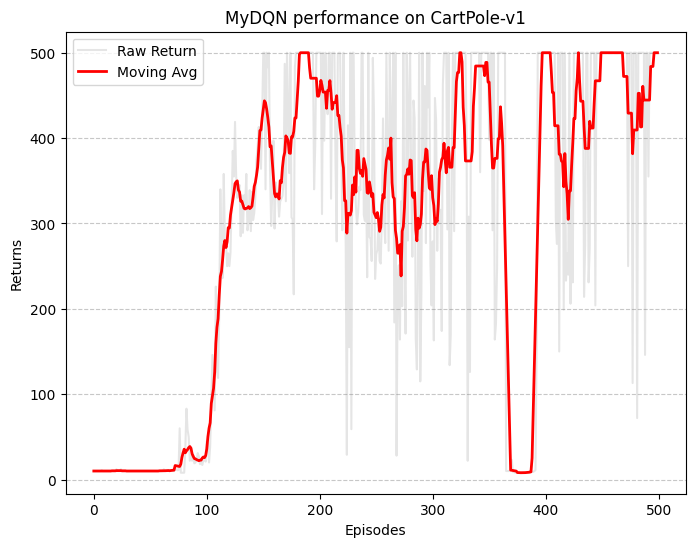

In [3]:
# 常规RL超参
gamma = 0.98
epsilon = 0.01 # PS: 虽然这里设为了 0.01（很小的固定探索），通常 DQN 会采用衰减的 epsilon。

# Target Network & Replay Buffer
target_update = 10 # 每进行 10 次 update，就同步一次目标网络
buffer_size = 10000 # 回放池的容量，最多存储 10000 条数据；先进先出
minimal_size = 500 # 回放池里存够了 500 条数据后，模型才真正开始通过反向传播进行学习。

# Pytorch：常规 DL 超参
num_episodes = 500 # episode=回合数=trajectory 数
batch_size = 64 # 每次从回放池中抽取 64 条数据进行训练。
hidden_dim = 128
lr = 2e-3
device = torch.device(
    "cuda" if torch.cuda.is_available()
    #else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

env_name = 'CartPole-v1' # CartPole-v1 vs CartPole-v0: 默认500步自动截断
# set_seed(SEED) # 锁全局随机种子，放在 setup_experiment 里了
env = setup_experiment(env_name, SEED) # env = gym.make(env_name) #env = gym.make(env_name, render_mode="human") # "human" 模式会直接弹出一个 GUI 窗口 # 注意truncated 的设计：GUI 可能会导致环境的 step 函数执行时间过长，超过了 Gym 的默认时间限制，从而触发 truncated=True，导致 episode 提前结束。

replay_buffer = ReplayBuffer(buffer_size)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = MyDQN(state_dim, hidden_dim, action_dim, lr, gamma, epsilon,
            target_update,device)

return_list = rl_utils.train_off_policy_agent(
    agent=agent,
    env=env,
    replay_buffer=replay_buffer,
    num_episodes=num_episodes,
    batch_size=batch_size,
    minimal_size=minimal_size,
    seed=SEED
)

plot_returns_combined(return_list=return_list,
                      env_name=env_name,algo_name="MyDQN",window_size=9)

# Iteration 0: 100%|██████████| 50/50 [00:00<00:00, 764.86it/s, episode=50,
# return=9.300]
# Iteration 1: 100%|██████████| 50/50 [00:04<00:00, 10.66it/s, episode=100,
# return=12.300]
# Iteration 2: 100%|██████████| 50/50 [00:24<00:00,  2.05it/s, episode=150,
# return=123.000]
# Iteration 3: 100%|██████████| 50/50 [01:25<00:00,  1.71s/it, episode=200,
# return=153.600]
# Iteration 4: 100%|██████████| 50/50 [01:30<00:00,  1.80s/it, episode=250,
# return=180.500]
# Iteration 5: 100%|██████████| 50/50 [01:24<00:00,  1.68s/it, episode=300,
# return=185.000]
# Iteration 6: 100%|██████████| 50/50 [01:32<00:00,  1.85s/it, episode=350,
# return=193.900]
# Iteration 7: 100%|██████████| 50/50 [01:31<00:00,  1.84s/it, episode=400,
# return=196.600]
# Iteration 8: 100%|██████████| 50/50 [01:33<00:00,  1.88s/it, episode=450,
# return=193.800]
# Iteration 9: 100%|██████████| 50/50 [01:34<00:00,  1.88s/it, episode=500,
# return=200.000]


In [4]:
# 结果可视化
show_live_performance(env_name, agent,seed=SEED, episodes=3)

可视化窗口已关闭


> return 来回震荡：  
> Target不稳定问题；灾难性遗忘问题；  
> 其他：lr；epsilon（乱走导致的 epsilon 提前结束，导致评估指标 return 显示的比较低）

> PS:
Double DQN (DDQN)：解决 Q 值过高估计问题，让学习更理性。  
Dueling DQN：把“状态好不好”和“动作好不好”分开学，让模型更懂环境。  
Prioritized Experience Replay (PER)：重点保留那些“快倒了”的经验，不让它们被轻易挤出池子，解决灾难性遗忘。  
Soft Update (软更新)：每步都同步 0.01% 的参数, 是目标平滑

> 模型在“学习新动作”的同时，“弄乱了旧记忆”。这正是强化学习最迷人也最折磨人的地方——它是一个动态的、自我博弈的过程，而不是死记硬背。

Q：是遇见的没见过的情形还是模型会学坏？早停是否合理？

## Actor-Critic

Iteration 9: 100%|██████████| 100/100 [00:02<00:00, 41.25it/s, episode=1000, return=500.000]


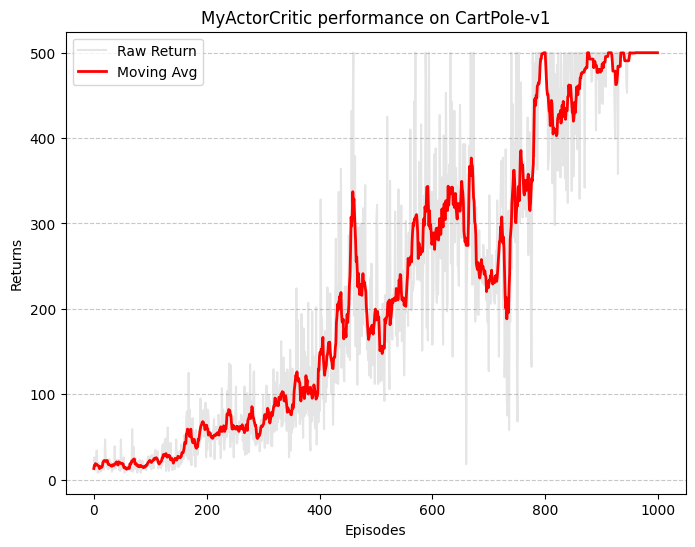

In [5]:
actor_lr = 1e-3
critic_lr = 1e-2
num_episodes = 1000
hidden_dim = 128
gamma = 0.98
device = torch.device("cuda") if torch.cuda.is_available() else torch.device(
    "cpu")

env_name = 'CartPole-v1'
env = setup_experiment(env_name, SEED) 
# env = gym.make(env_name) 

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = MyActorCritic(state_dim, hidden_dim, action_dim, actor_lr, critic_lr,
                    gamma, device)

# 注意：传入 SEED
return_list = rl_utils.train_on_policy_agent(env, agent, num_episodes,seed=SEED)

# 修改名称
plot_returns_combined(return_list=return_list,
                      env_name=env_name,algo_name="MyActorCritic",window_size=9)

# Iteration 0: 100%|██████████| 100/100 [00:00<00:00, 184.32it/s, episode=100,
# return=21.100]
# Iteration 1: 100%|██████████| 100/100 [00:01<00:00, 98.31it/s, episode=200,
# return=72.800]
# Iteration 2: 100%|██████████| 100/100 [00:01<00:00, 58.72it/s, episode=300,
# return=109.300]
# Iteration 3: 100%|██████████| 100/100 [00:04<00:00, 23.14it/s, episode=400,
# return=163.000]
# Iteration 4: 100%|██████████| 100/100 [00:08<00:00, 11.78it/s, episode=500,
# return=193.600]
# Iteration 5: 100%|██████████| 100/100 [00:08<00:00, 11.23it/s, episode=600,
# return=195.900]
# Iteration 6: 100%|██████████| 100/100 [00:08<00:00, 11.55it/s, episode=700,
# return=199.100]
# Iteration 7: 100%|██████████| 100/100 [00:09<00:00, 10.75it/s, episode=800,
# return=186.900]
# Iteration 8: 100%|██████████| 100/100 [00:08<00:00, 11.73it/s, episode=900,
# return=200.000]
# Iteration 9: 100%|██████████| 100/100 [00:08<00:00, 12.05it/s, episode=1000,
# return=200.000]

In [6]:
# 结果可视化
show_live_performance(env_name, agent,seed=SEED, episodes=3)

回合 1 结束，得分: 500.0
回合 2 结束，得分: 500.0
回合 3 结束，得分: 500.0
可视化窗口已关闭


## TRPO 离散

Iteration 9: 100%|██████████| 80/80 [00:01<00:00, 42.06it/s, episode=800, return=367.900]


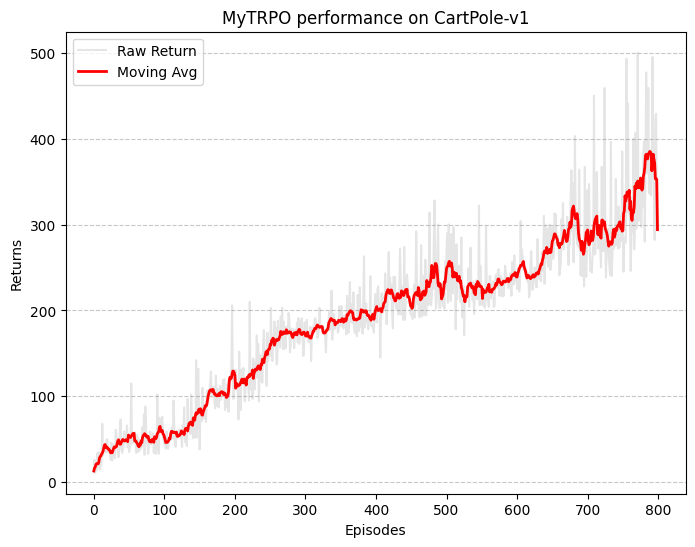

In [7]:
num_episodes = 800  # 500
hidden_dim = 128
gamma = 0.98
lmbda = 0.95
critic_lr = 1e-2
kl_constraint = 0.0005
alpha = 0.5
device = torch.device("cuda") if torch.cuda.is_available() else torch.device(
    "cpu")

env_name = 'CartPole-v1'
env = setup_experiment(env_name, SEED) 
# env = gym.make(env_name)

agent = MyTRPO(hidden_dim, env.observation_space, env.action_space, lmbda,
             kl_constraint, alpha, critic_lr, gamma, device)
return_list = rl_utils.train_on_policy_agent(env, agent, num_episodes,seed=SEED)

# 修改名称
plot_returns_combined(return_list=return_list,
                      env_name=env_name,algo_name="MyTRPO",window_size=9)

# Iteration 0: 100%|██████████| 50/50 [00:02<00:00, 16.85it/s, episode=50,
# return=139.200]
# Iteration 1: 100%|██████████| 50/50 [00:03<00:00, 16.55it/s, episode=100,
# return=150.500]
# Iteration 2: 100%|██████████| 50/50 [00:03<00:00, 14.21it/s, episode=150,
# return=184.000]
# Iteration 3: 100%|██████████| 50/50 [00:03<00:00, 14.15it/s, episode=200,
# return=183.600]
# Iteration 4: 100%|██████████| 50/50 [00:03<00:00, 13.96it/s, episode=250,
# return=183.500]
# Iteration 5: 100%|██████████| 50/50 [00:03<00:00, 13.29it/s, episode=300,
# return=193.700]
# Iteration 6: 100%|██████████| 50/50 [00:03<00:00, 14.08it/s, episode=350,
# return=199.500]
# Iteration 7: 100%|██████████| 50/50 [00:03<00:00, 13.36it/s, episode=400,
# return=200.000]
# Iteration 8: 100%|██████████| 50/50 [00:03<00:00, 13.33it/s, episode=450,
# return=200.000]
# Iteration 9: 100%|██████████| 50/50 [00:03<00:00, 13.08it/s, episode=500,
# return=200.000]

In [8]:
# 结果可视化
show_live_performance(env_name, agent,seed=SEED, episodes=3)

回合 1 结束，得分: 384.0
回合 2 结束，得分: 205.0
回合 3 结束，得分: 184.0
可视化窗口已关闭


## PPO 离散

Iteration 9: 100%|██████████| 50/50 [00:01<00:00, 33.50it/s, episode=500, return=500.000]


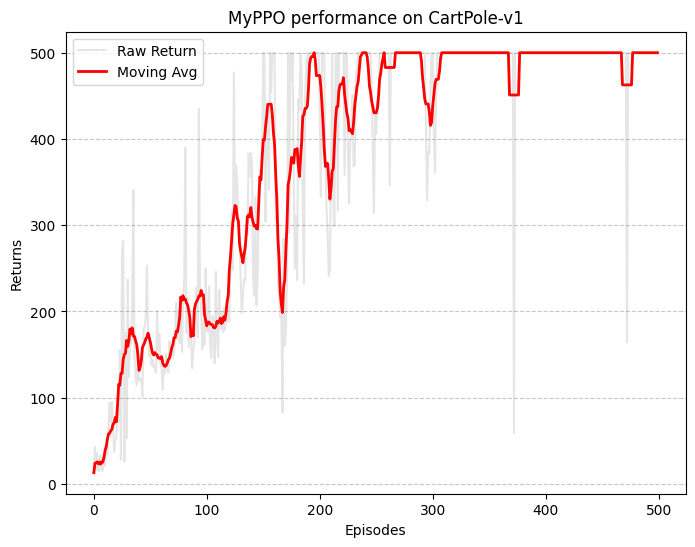

In [9]:
actor_lr = 1e-3
critic_lr = 1e-2
num_episodes = 500
hidden_dim = 128
gamma = 0.98
lmbda = 0.95
epochs = 10
eps = 0.2
device = torch.device("cuda") if torch.cuda.is_available() else torch.device(
    "cpu")

env_name = 'CartPole-v1'
env = setup_experiment(env_name, SEED) 
# env = gym.make(env_name)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = MyPPO(state_dim, hidden_dim, action_dim, actor_lr, critic_lr, lmbda,
            epochs, eps, gamma, device)

return_list = rl_utils.train_on_policy_agent(env, agent, num_episodes,seed=SEED)

# 修改名称
plot_returns_combined(return_list=return_list,
                      env_name=env_name,algo_name="MyPPO",window_size=9)

# Iteration 0: 100%|██████████| 50/50 [00:10<00:00,  4.81it/s, episode=50,
# return=183.200]
# Iteration 1: 100%|██████████| 50/50 [00:22<00:00,  2.24it/s, episode=100,
# return=191.400]
# Iteration 2: 100%|██████████| 50/50 [00:22<00:00,  2.24it/s, episode=150,
# return=199.900]
# Iteration 3: 100%|██████████| 50/50 [00:21<00:00,  2.33it/s, episode=200,
# return=200.000]
# Iteration 4: 100%|██████████| 50/50 [00:21<00:00,  2.29it/s, episode=250,
# return=200.000]
# Iteration 5: 100%|██████████| 50/50 [00:22<00:00,  2.22it/s, episode=300,
# return=200.000]
# Iteration 6: 100%|██████████| 50/50 [00:23<00:00,  2.14it/s, episode=350,
# return=200.000]
# Iteration 7: 100%|██████████| 50/50 [00:23<00:00,  2.16it/s, episode=400,
# return=200.000]
# Iteration 8: 100%|██████████| 50/50 [00:22<00:00,  2.23it/s, episode=450,
# return=200.000]
# Iteration 9: 100%|██████████| 50/50 [00:22<00:00,  2.25it/s, episode=500,
# return=200.000]

In [10]:
# 结果可视化
show_live_performance(env_name, agent,seed=SEED, episodes=3)

回合 1 结束，得分: 500.0
回合 2 结束，得分: 285.0
回合 3 结束，得分: 500.0
可视化窗口已关闭


## SAC 离散

Iteration 9: 100%|██████████| 50/50 [00:13<00:00,  3.76it/s, episode=500, return=184.400]


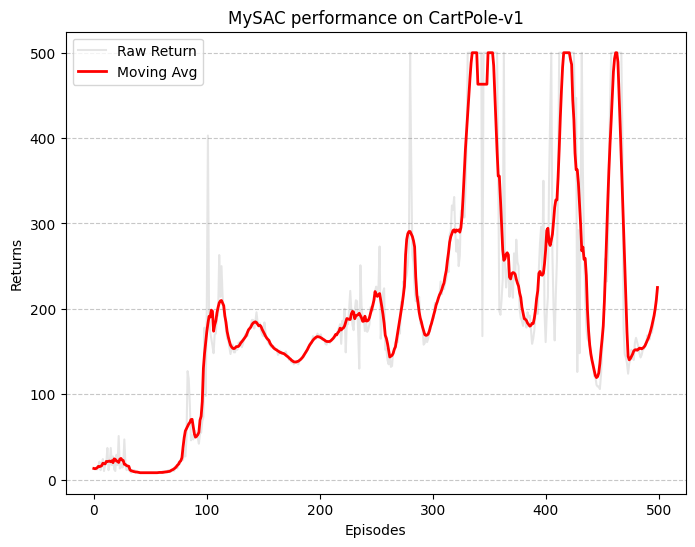

In [11]:
actor_lr = 1e-3
critic_lr = 1e-2
alpha_lr = 1e-2
num_episodes = 500
hidden_dim = 128
gamma = 0.98
tau = 0.005  # 软更新参数
buffer_size = 10000
minimal_size = 500
batch_size = 64
target_entropy = -1
device = torch.device("cuda") if torch.cuda.is_available() else torch.device(
    "cpu")

env_name = 'CartPole-v1'
env = setup_experiment(env_name, SEED) 
# env = gym.make(env_name)

replay_buffer = rl_utils.ReplayBuffer(buffer_size)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = MySAC(state_dim, hidden_dim, action_dim, actor_lr, critic_lr, alpha_lr,
            target_entropy, tau, gamma, device)

return_list = rl_utils.train_off_policy_agent(env, agent, num_episodes,
                                              replay_buffer, minimal_size,
                                              batch_size,seed=SEED)

# 修改名称
plot_returns_combined(return_list=return_list,
                      env_name=env_name,algo_name="MySAC",window_size=9)

# Iteration 0: 100%|██████████| 20/20 [00:00<00:00, 193.82it/s, episode=20,
# return=19.700]
# Iteration 1: 100%|██████████| 20/20 [00:00<00:00, 29.39it/s, episode=40,
# return=10.600]
# Iteration 2: 100%|██████████| 20/20 [00:00<00:00, 26.38it/s, episode=60,
# return=10.000]
# Iteration 3: 100%|██████████| 20/20 [00:00<00:00, 24.32it/s, episode=80,
# return=9.800]
# Iteration 4: 100%|██████████| 20/20 [00:00<00:00, 26.86it/s, episode=100,
# return=9.100]
# Iteration 5: 100%|██████████| 20/20 [00:00<00:00, 26.87it/s, episode=120,
# return=9.500]
# Iteration 6: 100%|██████████| 20/20 [00:07<00:00,  2.64it/s, episode=140,
# return=178.400]
# Iteration 7: 100%|██████████| 20/20 [00:15<00:00,  1.33it/s, episode=160,
# return=200.000]
# Iteration 8: 100%|██████████| 20/20 [00:15<00:00,  1.31it/s, episode=180,
# return=200.000]
# Iteration 9: 100%|██████████| 20/20 [00:15<00:00,  1.32it/s, episode=200,
# return=197.600]

In [12]:
# 结果可视化
show_live_performance(env_name, agent,seed=SEED, episodes=3)

回合 1 结束，得分: 246.0
回合 2 结束，得分: 281.0
回合 3 结束，得分: 293.0
可视化窗口已关闭
